Sonal Ambhore (CS23164)

In [26]:
import os
print(os.listdir())

['.config', 'daily_weather.csv', 'daily_weather (1).csv', 'daily_weather (2).csv', 'sample_data']


In [27]:
from google.colab import files
uploaded = files.upload()

Saving daily_weather.csv to daily_weather (3).csv


In [28]:
import os
print(os.listdir())

['.config', 'daily_weather.csv', 'daily_weather (1).csv', 'daily_weather (2).csv', 'daily_weather (3).csv', 'sample_data']


In [29]:
import pandas as pd
df = pd.read_csv("/content/daily_weather.csv")
df.head()

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
0,0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.0,0.0,42.420000,36.160000
1,1,917.347688,71.403843,101.935179,2.443009,140.471548,3.533324,0.0,0.0,24.328697,19.426597
2,2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.0,20.0,8.900000,14.460000
3,3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.0,0.0,12.189102,12.742547
4,4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.9,14730.0,92.410000,76.740000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   number                  1095 non-null   int64  
 1   air_pressure_9am        1092 non-null   float64
 2   air_temp_9am            1090 non-null   float64
 3   avg_wind_direction_9am  1091 non-null   float64
 4   avg_wind_speed_9am      1092 non-null   float64
 5   max_wind_direction_9am  1092 non-null   float64
 6   max_wind_speed_9am      1091 non-null   float64
 7   rain_accumulation_9am   1089 non-null   float64
 8   rain_duration_9am       1092 non-null   float64
 9   relative_humidity_9am   1095 non-null   float64
 10  relative_humidity_3pm   1095 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 94.2 KB


In [31]:
print(df.columns)

Index(['number', 'air_pressure_9am', 'air_temp_9am', 'avg_wind_direction_9am',
       'avg_wind_speed_9am', 'max_wind_direction_9am', 'max_wind_speed_9am',
       'rain_accumulation_9am', 'rain_duration_9am', 'relative_humidity_9am',
       'relative_humidity_3pm'],
      dtype='object')


In [32]:
df.dropna(inplace=True)
X = df.drop("relative_humidity_3pm", axis=1)
y = df["relative_humidity_3pm"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.7498538176903975
MSE: 139.52761384732574


In [37]:
depths = [2, 4, 6, 8, 10, 15]
r2_scores = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

print(r2_scores)

[0.786543130792386, 0.8277761070968931, 0.8059797307113851, 0.802523744340438, 0.7654605289539498, 0.7342606741757212]


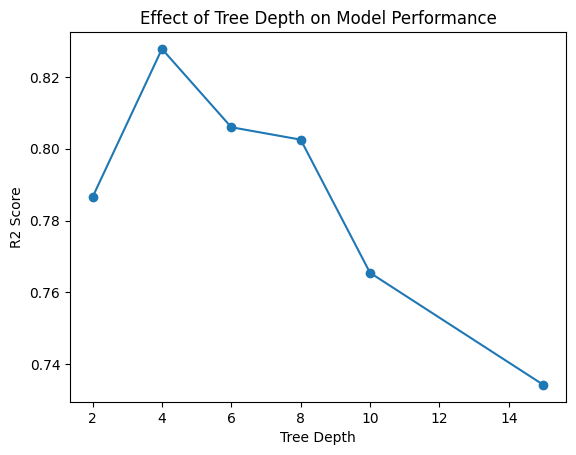

In [38]:
import matplotlib.pyplot as plt

plt.plot(depths, r2_scores, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.title("Effect of Tree Depth on Model Performance")
plt.show()

In [39]:
criteria = ["squared_error", "absolute_error"]

for crit in criteria:
    model = DecisionTreeRegressor(
        criterion=crit,
        max_depth=6,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\nCriterion:", crit)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))


Criterion: squared_error
R2 Score: 0.8059797307113851
MSE: 108.22146059519063

Criterion: absolute_error
R2 Score: 0.7886505463797847
MSE: 117.88740759219921
